# Heart Disease Prediction — Model Evaluation Notebook

Loads the models and held-out test split produced by `machine_learning.ipynb` and evaluates them with:

1. Classification metrics (accuracy, precision, recall, F1)
2. Confusion matrix
3. ROC curve & AUC (all models compared)
4. Feature importance (best model)

*Run `machine_learning.ipynb` first — this notebook depends on its saved artifacts.*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load Artifacts

In [2]:
fitted_pipelines = joblib.load('fitted_pipelines.joblib')
best_model_name = joblib.load('best_model_name.joblib')

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').iloc[:, 0]

print(f"Best model: {best_model_name}")
print(f"Test set shape: {X_test.shape}")
print(f"Models available: {list(fitted_pipelines.keys())}")


Best model: LogisticRegression
Test set shape: (184, 16)
Models available: ['LogisticRegression', 'RandomForest', 'GradientBoosting']


## 2. Classification Metrics — All Models

In [3]:
metrics_rows = []
for name, pipe in fitted_pipelines.items():
    preds = pipe.predict(X_test)
    metrics_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('F1', ascending=False)
metrics_df.round(4)


,Accuracy,Precision,Recall,F1
Model,,,,
LogisticRegression,0.8913,0.9020,0.9020,0.902
GradientBoosting,0.8913,0.9020,0.9020,0.902
RandomForest,0.8750,0.8692,0.9118,0.890


In [4]:
best_pipeline = fitted_pipelines[best_model_name]
best_preds = best_pipeline.predict(X_test)

print(f"Detailed classification report — {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=['No Disease', 'Disease']))


Detailed classification report — LogisticRegression

              precision    recall  f1-score   support

  No Disease       0.88      0.88      0.88        82
     Disease       0.90      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



## 3. Confusion Matrix

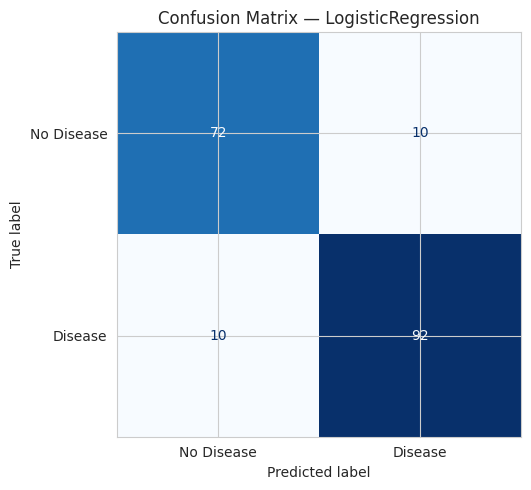

True Negatives:  72
False Positives: 10
False Negatives: 10
True Positives:  92


In [5]:
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")


## 4. ROC Curve — All Models

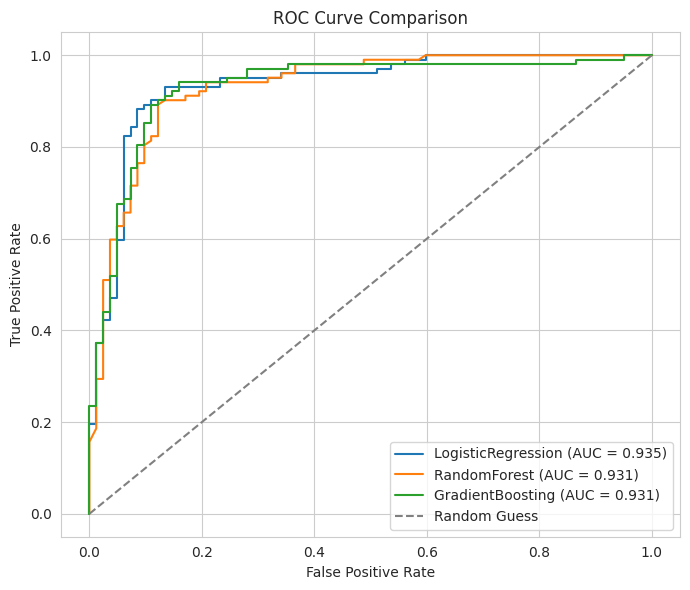

In [6]:
plt.figure(figsize=(7, 6))

for name, pipe in fitted_pipelines.items():
    probs = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 5. Feature Importance

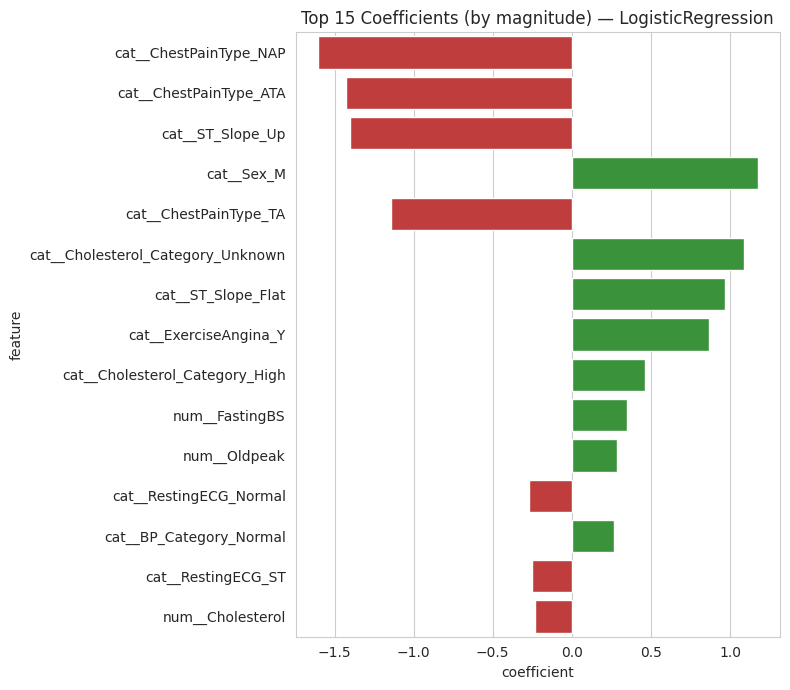

In [7]:
def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps['preprocessor']
    return preprocessor.get_feature_names_out()

model_step = best_pipeline.named_steps['classifier']

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    feat_names = get_feature_names(best_pipeline)
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(8, 7))
    sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    fi_df.reset_index(drop=True)
elif hasattr(model_step, 'coef_'):
    coefs = model_step.coef_[0]
    feat_names = get_feature_names(best_pipeline)
    fi_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs})
    fi_df['abs_coef'] = fi_df['coefficient'].abs()
    fi_df = fi_df.sort_values('abs_coef', ascending=False).head(15)

    plt.figure(figsize=(8, 7))
    colors = ['#d62728' if c < 0 else '#2ca02c' for c in fi_df['coefficient']]
    sns.barplot(data=fi_df, x='coefficient', y='feature', palette=colors)
    plt.title(f'Top 15 Coefficients (by magnitude) — {best_model_name}')
    plt.tight_layout()
    plt.show()

    fi_df.reset_index(drop=True)
else:
    print("Selected model does not expose feature importances or coefficients directly.")


## 6. Summary

- Best model by F1 on the held-out test set is reported above, with full precision/recall/F1 breakdown.
- The confusion matrix shows the trade-off between false positives (unnecessary follow-up) and false negatives (missed diagnosis) — clinically, minimizing false negatives is usually the priority.
- ROC/AUC comparison across all three models gives a threshold-independent view of discriminative power.
- Feature importance highlights which clinical variables (including the engineered features from `machine_learning.ipynb`) drive predictions most.
